## CNN models

### Q1 [1"]: Why are CNNs preferred over fully connected networks (MLPs) for image-based tasks?


# **MLPs drawbacks:**
Too many parameters for images → computationally expensive and overfitting

Not translation invariant (same object in different positions gives different outputs)
# **CNN advantages:**
Local feature learning (nearby pixels are related)

Translation invariance via convolution and pooling

Hierarchical features (edges → shapes → objects)

Fewer parameters due to weight sharing → more efficient

Conclusion: CNNs are preferred because they exploit spatial structure, are more efficient, and generalize better for images.

### Q2 [1"]:
- Explain how saliency maps can help in interpreting a CNN model's decision.

**Interpretation**

Feature Importance: They act as a form of "feature importance" for visual data.

Gradient-Based Insights: Methods compute the gradients of the output class score with respect to the input pixels. This identifies how much each individual pixel influenced the final classification.

Visualizing Activations: Popular techniques like Grad-CAM highlight significant regions by analyzing the activations of deep CNN layers.

Decision Validation: They can reveal if a model is focusing on the actual object (like a dog) or irrelevant background features.

**Common Methods**

Gradient Methods: Directly measuring pixel influence via backpropagation.

Occlusion Methods: Systematically blocking parts of the image to observe how the output score drops, revealing which parts are most critical for a correct prediction.

### Q3 [2"]:
- Discuss the trade-offs between using YOLO and Faster R-CNN for real-time bridge damage detection via drone imagery. Which would you recommend and why?

**YOLO**

Speed: It is a one-stage, proposal-free framework that processes the entire image in a single pass.
Real-Time Capability: It is designed for real-time applications, making it ideal for processing live drone feeds.
Trade-off: It is generally less accurate than R-CNN models and struggles with small objects or groups of small objects. In bridge imagery, this might lead to missing fine-line cracks or small areas of corrosion.

**R-CNN**

Precision: As a two-stage detector, it uses a Region Proposal Network (RPN) to identify potential damage areas before classifying them.
Accuracy: It is better suited for detecting small, overlapping objects or details that require high resolution. This is critical for identifying subtle structural defects like hair-line cracks.
Trade-off: Even though it is significantly faster than the original R-CNN, it is still much slower than YOLO ($0.2$ vs $49$ seconds in test-time speed examples).

**Recommendation: Faster R-CNN**

For bridge damage detection, I recommend Faster R-CNN.

Priority of Precision: In structural health monitoring, missing a small but critical defect (like a fatigue crack) is a higher risk than a delay in processing time.
Non-Critical Speed: While drones fly in "real-time," the actual damage analysis does not usually require the millisecond latency that YOLO provides for tasks like autonomous driving.
Small Object Detection: Drone imagery often captures small defects from a distance; Faster R-CNN’s ability to handle fine detail makes it more reliable for professional engineering assessments.

### Q4 [4"]:
- Load pretrained model ```MobileNetV2``` and generate a saliency map for the image ```bear.jpeg```

Loading MobileNetV2 model...
Running prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Top Prediction: 'ice_bear' (Index: 296, Probability: 0.8160)
Generating saliency map...
Visualization saved to: saliency_map_visualization.png


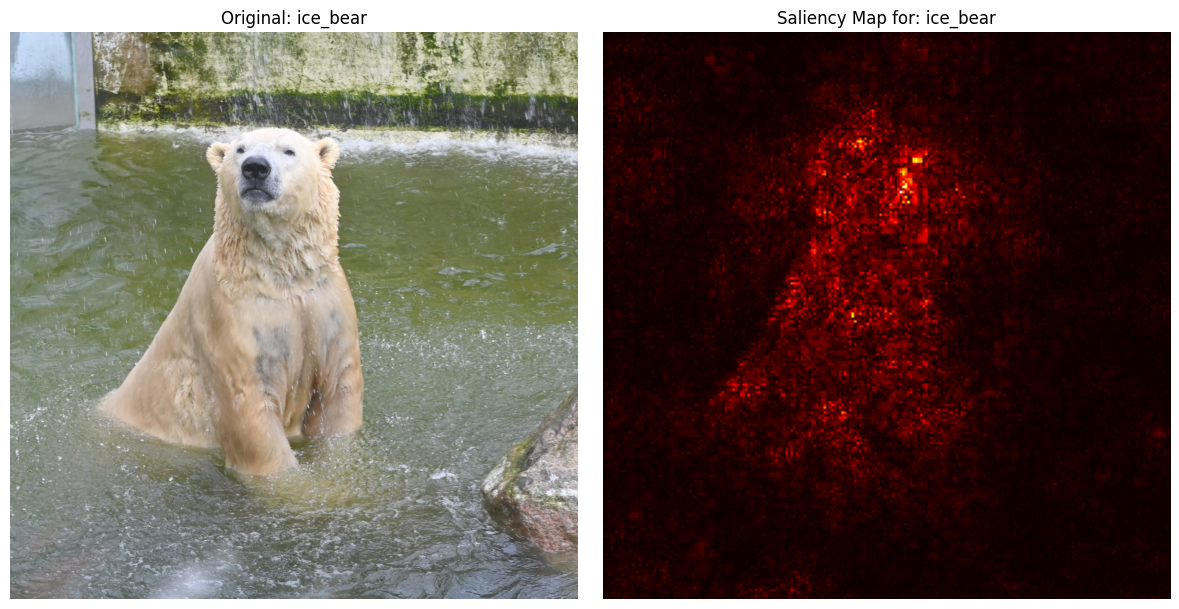

In [7]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image
import urllib.request

# 1. Download and Load the Input Image from Google Drive
# Extract the file ID from your Google Drive link
file_id = "1EAMi94COF73qwOgvYEBlXl1CKv_PykBp"
# Construct the direct download URL
url = f"https://drive.google.com/uc?id={file_id}"
input_image_path = "downloaded_image.jpg"

print("Downloading image from Google Drive...")
# Download the image
urllib.request.urlretrieve(url, input_image_path)

# Open and resize the image
original_img = PIL.Image.open(input_image_path)
target_size = (224, 224)
img = original_img.resize(target_size)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# 2. Load Pretrained MobileNetV2
print("Loading MobileNetV2 model...")
model = MobileNetV2(weights='imagenet', include_top=True, classifier_activation='softmax')

# 3. Define the Saliency Map Function
def generate_saliency_map(model, img_array, class_index):
    with tf.GradientTape() as tape:
        images = tf.Variable(img_array, dtype=tf.float32)
        tape.watch(images)
        predictions = model(images)
        loss = predictions[:, class_index]

    gradients = tape.gradient(loss, images)
    abs_gradients = tf.abs(gradients)
    saliency_map = tf.reduce_sum(abs_gradients, axis=-1)

    return saliency_map.numpy().squeeze()

# 4. Run the Prediction to find the Top Class
print("Running prediction...")
preds = model.predict(img_array)
decoded_preds = decode_predictions(preds, top=1)[0][0]
top_class_label = decoded_preds[1]
top_class_index = np.argmax(preds[0])

print(f"Top Prediction: '{top_class_label}' (Index: {top_class_index}, Probability: {decoded_preds[2]:.4f})")

# 5. Generate the Saliency Map for the Top Class
print("Generating saliency map...")
saliency = generate_saliency_map(model, img_array, top_class_index)

# 6. Normalize the Saliency Map for Visualization
saliency_normalized = (saliency - saliency.min()) / (saliency.max() - saliency.min())

# 7. Visualize the Results
plt.figure(figsize=(12, 6))

# Subplot 1: The Original Input Image
plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title(f"Original: {top_class_label}")
plt.axis('off')

# Subplot 2: The Generated Saliency Map
plt.subplot(1, 2, 2)
plt.imshow(saliency_normalized, cmap='hot')
plt.title(f"Saliency Map for: {top_class_label}")
plt.axis('off')

# Adjust layout and show/save
plt.tight_layout()
output_visualization_path = "saliency_map_visualization.png"
plt.savefig(output_visualization_path)

print(f"Visualization saved to: {output_visualization_path}")
plt.show()

### Q5 [4"]:
- Use ```fasterrcnn_resnet50_fpn``` and ```yolov8n``` to detect objects in the image ```zoo.jpg```.
- Visualize the object detection results (see the course notebook for CNN)

Running Faster R-CNN...
Running YOLOv8n...

image 1/1 /content/zoo.jpg: 448x640 13 persons, 1 cow, 1 elephant, 1 cup, 1 cell phone, 166.8ms
Speed: 3.7ms preprocess, 166.8ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Object detection visualization saved to zoo_detection_comparison.png


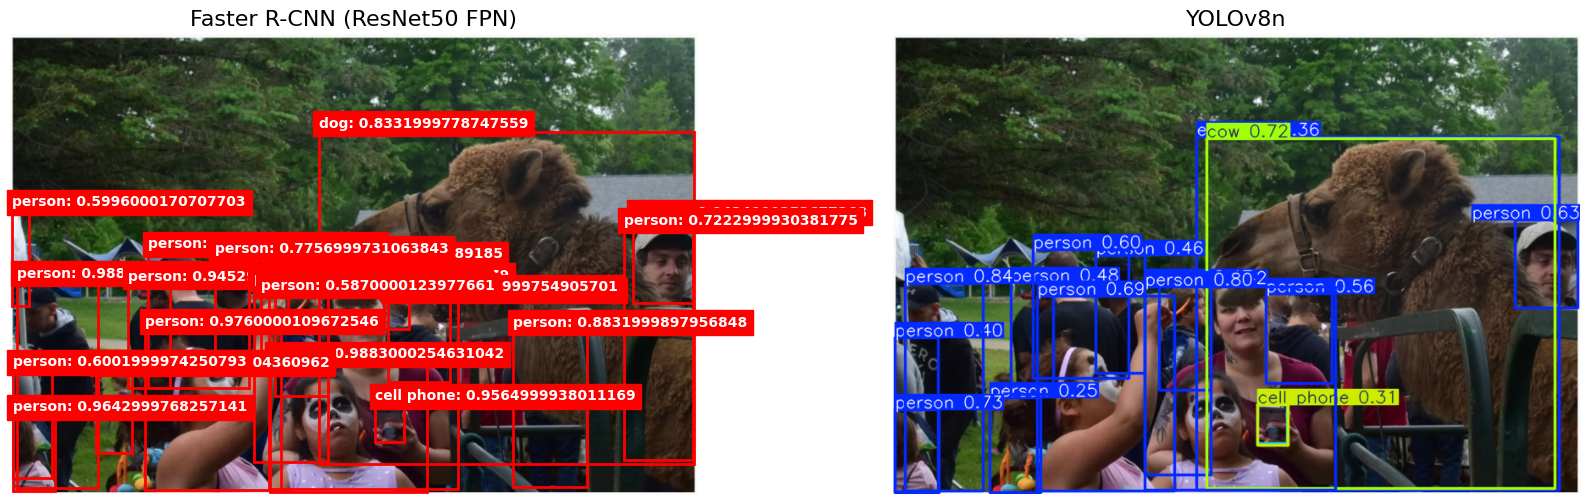

In [8]:

!pip install ultralytics torchvision

import urllib.request
from PIL import Image
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import cv2
from ultralytics import YOLO

# 1. Download image from Google Drive
file_id = "1IZbh32cZjSJG5ZQXXTwWFBbhBhmXPgOH"
url = f"https://drive.google.com/uc?id={file_id}"
img_path = "zoo.jpg"

print("Downloading zoo.jpg...")
urllib.request.urlretrieve(url, img_path)

# Read the image
img = Image.open(img_path).convert("RGB")
img_tensor = F.to_tensor(img).unsqueeze(0)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# ==========================================
# 2. Faster R-CNN Detection
# ==========================================
print("Running Faster R-CNN...")
# Load the pretrained model
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model_frcnn = fasterrcnn_resnet50_fpn(weights=weights)
model_frcnn.eval()

# Run inference
with torch.no_grad():
    prediction = model_frcnn(img_tensor)[0]

ax[0].imshow(img)
ax[0].set_title("Faster R-CNN (ResNet50 FPN)", fontsize=16)

# Set a threshold to filter out weak detections
score_threshold = 0.5
for element in range(len(prediction["boxes"])):
    boxes = prediction["boxes"][element].cpu().numpy()
    score = np.round(prediction["scores"][element].cpu().numpy(), decimals=4)

    if score > score_threshold:
        label_idx = prediction["labels"][element].item()
        label = weights.meta["categories"][label_idx]

        # Draw the bounding box
        rect = patches.Rectangle((boxes[0], boxes[1]), boxes[2] - boxes[0], boxes[3] - boxes[1],
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax[0].add_patch(rect)
        # Add the label and score
        ax[0].text(boxes[0], boxes[1]-5, f"{label}: {score}", color='white', fontsize=10,
                   backgroundcolor='red', fontweight='bold')

ax[0].axis('off')

# ==========================================
# 3. YOLOv8n Detection
# ==========================================
print("Running YOLOv8n...")
# Load the pretrained YOLOv8 nano model
model_yolo = YOLO('yolov8n.pt')

# Run inference
results = model_yolo(img_path)

# YOLO provides a built-in plotting function for bounding boxes
res_plotted = results[0].plot()

# Convert from BGR (OpenCV's default) to RGB for Matplotlib visualization
res_plotted_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

ax[1].imshow(res_plotted_rgb)
ax[1].set_title("YOLOv8n", fontsize=16)
ax[1].axis('off')

# ==========================================
# 4. Final Output Formatting
# ==========================================
plt.tight_layout()
output_path = "zoo_detection_comparison.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Object detection visualization saved to {output_path}")
plt.show()

# RNN Models

### Q1 [1"]:
- Why are RNNs better suited for modeling sequences compared to MLPs?

**1. Retention of Past Information (Hidden State)**

Internal Memory: RNN units are designed to remember what they have seen before by maintaining a hidden state ($h_t$).

Compressed History: This hidden state acts as a "memory" that contains compressed information about past conditions (e.g., prior traffic or temperature measurements).

Dynamic Updates: As new input ($x_t$) arrives, the hidden state is updated based on both that input and the previous state ($h_{t-1}$), allowing the model to build a continuous understanding of the sequence.

**2. Sensitivity to Temporal Order**

MLP Limitations: In an MLP, re-arranging the order of inputs produces the same result because the model treats samples as isolated features.

Sequential Context: RNNs explicitly model the dependencies between time steps. They process data as a sequence where the result of one step informs the next, making them capable of tasks like predicting the next car at an intersection or the next word in a sentence.

**3. Handling Long-Range Dependencies**

Sequential Understanding: While MLPs look at a fixed "window" of features, advanced RNN architectures like LSTM (Long Short-Term Memory) use dedicated memory cells and gates to capture dependencies over many time steps.

Gradient Flow: LSTMs include a "cell state" that allows information to pass through with minimal modification, helping the model learn long-term interactions that would otherwise be lost in a standard network.

### Q2 [1"]:
- What does it mean that an RNN “remembers” previous data points?

Internal Memory: Unlike MLPs, which treat inputs as isolated samples , RNNs maintain a hidden state ($h_t$). This acts as a "memory" that compresses information from previous time steps to influence current predictions.

Order Sensitivity: MLPs produce the same result even if input order is rearranged. RNNs are designed to process the inherent temporal flow of data, such as weather patterns or speech.

Dynamic Connectivity: Through "unfolding," information from step $t-1$ is passed to step $t$. This allows the model to understand context, like predicting traffic flow based on several prior minutes.

Long-Term Mastery (LSTM/GRU): While standard RNNs suffer from "vanishing gradients" over deep sequences , advanced units like LSTMs use a dedicated cell state ($c_t$) and gates to retain information over much longer durations.

### Q2 [2"]:
- Why is LSTM better at capturing long-term dependencies when compared to vanilla RNN?

LSTM (Long Short-Term Memory) is more effective than vanilla RNNs because it introduces a dedicated "highway" for information called the cell state, which allows data to persist over long durations without being significantly modified.

Solution to the limitations of vanilla RNNs:

The Vanishing Gradient Problem: In vanilla RNNs, gradients are repeatedly multiplied through deep, unfolded layers, causing them to "vanish" or "explode" over long sequences.

Cell State ($c_t$): Unlike the standard hidden state, the cell state passes information with minimal linear interaction, allowing gradients to flow across many time steps without disappearing.

Gating Mechanisms: LSTMs use three specific "gates" to manage memory selectively:

Forget Gate: Decides which old memories are no longer useful and should be discarded.

Input Gate: Determines which new information is worth adding to the cell state.

Output Gate: Controls which parts of the current memory should be passed on to the hidden state and the next time step.

Activation Control: These gates use sigmoid activations (outputting values between 0 and 1) to act as valves that either block ("0") or pass ("1") information.

In summary, while a vanilla RNN's memory is overwritten at every step, an LSTM has the architectural "permission" to hold onto a specific piece of information for as long as it remains relevant to the task.

### Q4 [4"]:
- Build an RNN, LSTM, and GRU for the data in ```min_temp.csv```
- Print their final validation loss
- Visulize their training loss and validation loss in a figure

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training RNN...
Training LSTM...
Training GRU...

Final Validation Losses:
RNN: 0.0054
LSTM: 0.0055
GRU: 0.0050


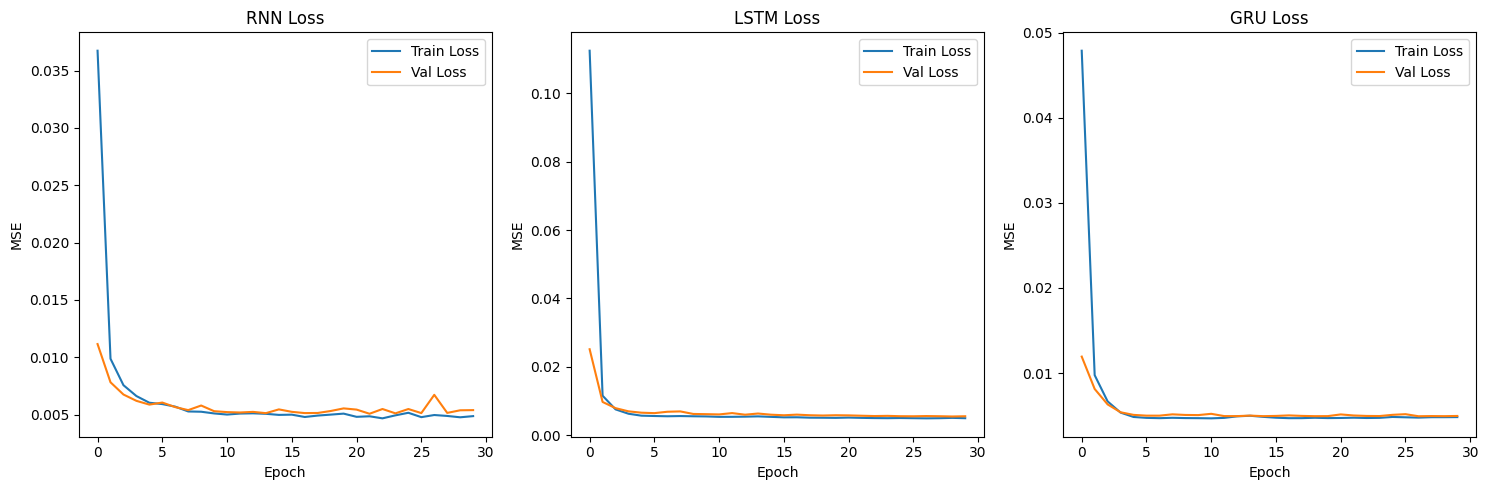

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

# 1. Load Data from Google Drive
# Extract the file ID from the sharing link
file_id = '1QeArnTI4ysR9cWMV3IZyxs_ZBx_MPWFm'
# Construct the direct download URL
url = f'https://drive.google.com/uc?id={file_id}'

print("Downloading and loading data...")
df = pd.read_csv(url)
data = df['TMIN'].values.reshape(-1, 1)

# 2. Scale
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. Create Sequences
seq_len = 30
X, y = [], []
for i in range(seq_len, len(scaled_data)):
    X.append(scaled_data[i-seq_len:i, 0])
    y.append(scaled_data[i, 0])
X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split
train_size = int(len(X) * 0.8)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

# 4. Define Model Builder
def build_and_train_model(layer_type):
    model = Sequential()
    if layer_type == 'RNN':
        model.add(SimpleRNN(32, input_shape=(X_train.shape[1], 1)))
    elif layer_type == 'LSTM':
        model.add(LSTM(32, input_shape=(X_train.shape[1], 1)))
    elif layer_type == 'GRU':
        model.add(GRU(32, input_shape=(X_train.shape[1], 1)))

    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    print(f"Training {layer_type}...")
    history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val), verbose=0)
    return history, model

# 5. Train Models
history_rnn, model_rnn = build_and_train_model('RNN')
history_lstm, model_lstm = build_and_train_model('LSTM')
history_gru, model_gru = build_and_train_model('GRU')

# 6. Final Validation Losses
print("\nFinal Validation Losses:")
print(f"RNN: {history_rnn.history['val_loss'][-1]:.4f}")
print(f"LSTM: {history_lstm.history['val_loss'][-1]:.4f}")
print(f"GRU: {history_gru.history['val_loss'][-1]:.4f}")

# 7. Plot
plt.figure(figsize=(15, 5))

# RNN Plot
plt.subplot(1, 3, 1)
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Val Loss')
plt.title('RNN Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

# LSTM Plot
plt.subplot(1, 3, 2)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

# GRU Plot
plt.subplot(1, 3, 3)
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Val Loss')
plt.title('GRU Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

plt.tight_layout()
plt.show()